Importing the Dependencies

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Data Collection and Processing

In [3]:
# loading the csv data to a Pandas DataFrame
heart_data = pd.read_csv('C:\\Users\\visha\\OneDrive\\Desktop\\projects\\Multiple_Heath_Disease_Predictor\\dataset\\heart.csv')

In [4]:
# print first 5 rows of the dataset
heart_data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [5]:
# number of rows and columns in the dataset
heart_data.shape

(303, 14)

In [6]:
# getting some info about the data
heart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [7]:
# checking for missing values
heart_data.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [8]:
# statistical measures about the data
heart_data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
sex,303.0,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
cp,303.0,0.966997,1.032052,0.0,0.0,1.0,2.0,3.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.528053,0.525860,0.0,0.0,1.0,1.0,2.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


array([[<Axes: title={'center': 'age'}>, <Axes: title={'center': 'sex'}>,
        <Axes: title={'center': 'cp'}>,
        <Axes: title={'center': 'trestbps'}>],
       [<Axes: title={'center': 'chol'}>,
        <Axes: title={'center': 'fbs'}>,
        <Axes: title={'center': 'restecg'}>,
        <Axes: title={'center': 'thalach'}>],
       [<Axes: title={'center': 'exang'}>,
        <Axes: title={'center': 'oldpeak'}>,
        <Axes: title={'center': 'slope'}>,
        <Axes: title={'center': 'ca'}>],
       [<Axes: title={'center': 'thal'}>,
        <Axes: title={'center': 'target'}>, <Axes: >, <Axes: >]],
      dtype=object)

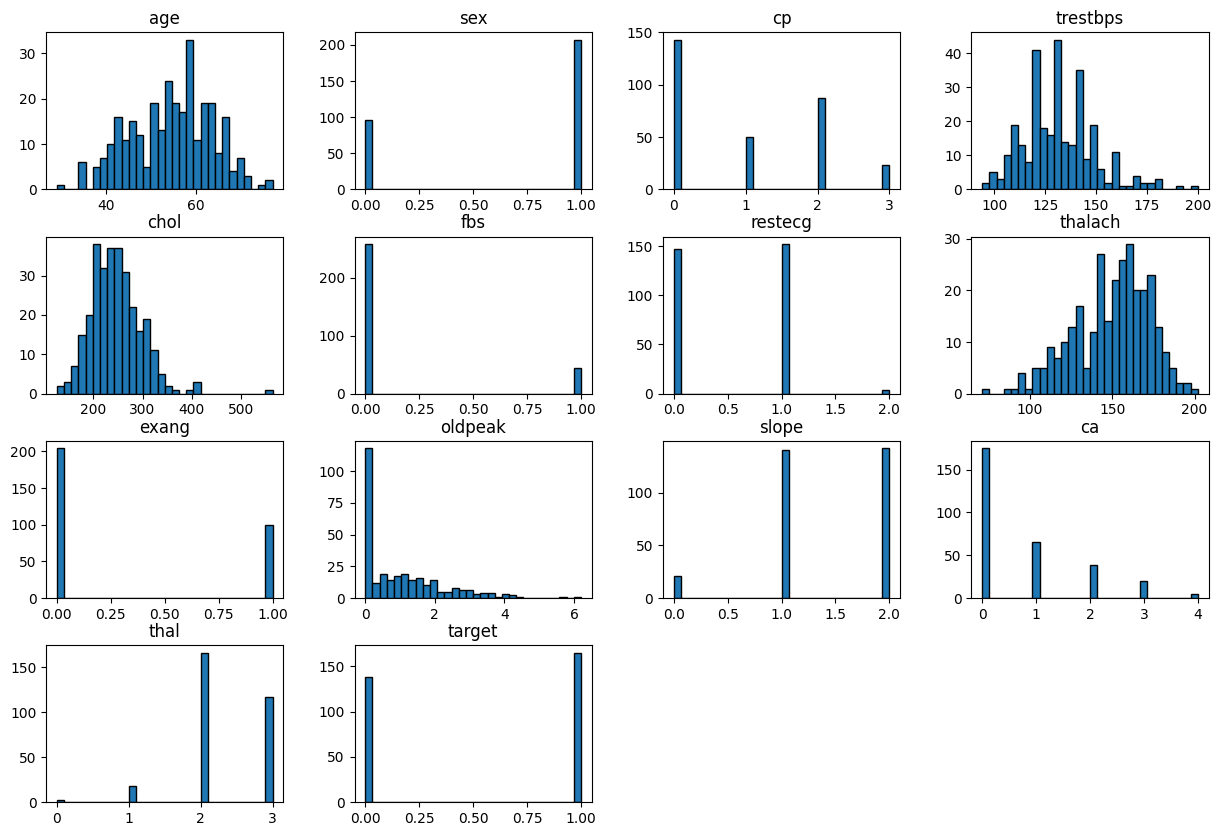

In [9]:
heart_data.hist(bins=30, figsize=(15, 10), edgecolor='black', grid=False)

In [10]:
heart_data.groupby('target').mean()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
target,,,,,,,,,,,,,
0,56.601449,0.826087,0.478261,134.398551,251.086957,0.159420,0.449275,139.101449,0.550725,1.585507,1.166667,1.166667,2.543478
1,52.496970,0.563636,1.375758,129.303030,242.230303,0.139394,0.593939,158.466667,0.139394,0.583030,1.593939,0.363636,2.121212


Splitting the Features and Target

In [11]:
X = heart_data.drop(columns='target', axis=1)
Y = heart_data['target']

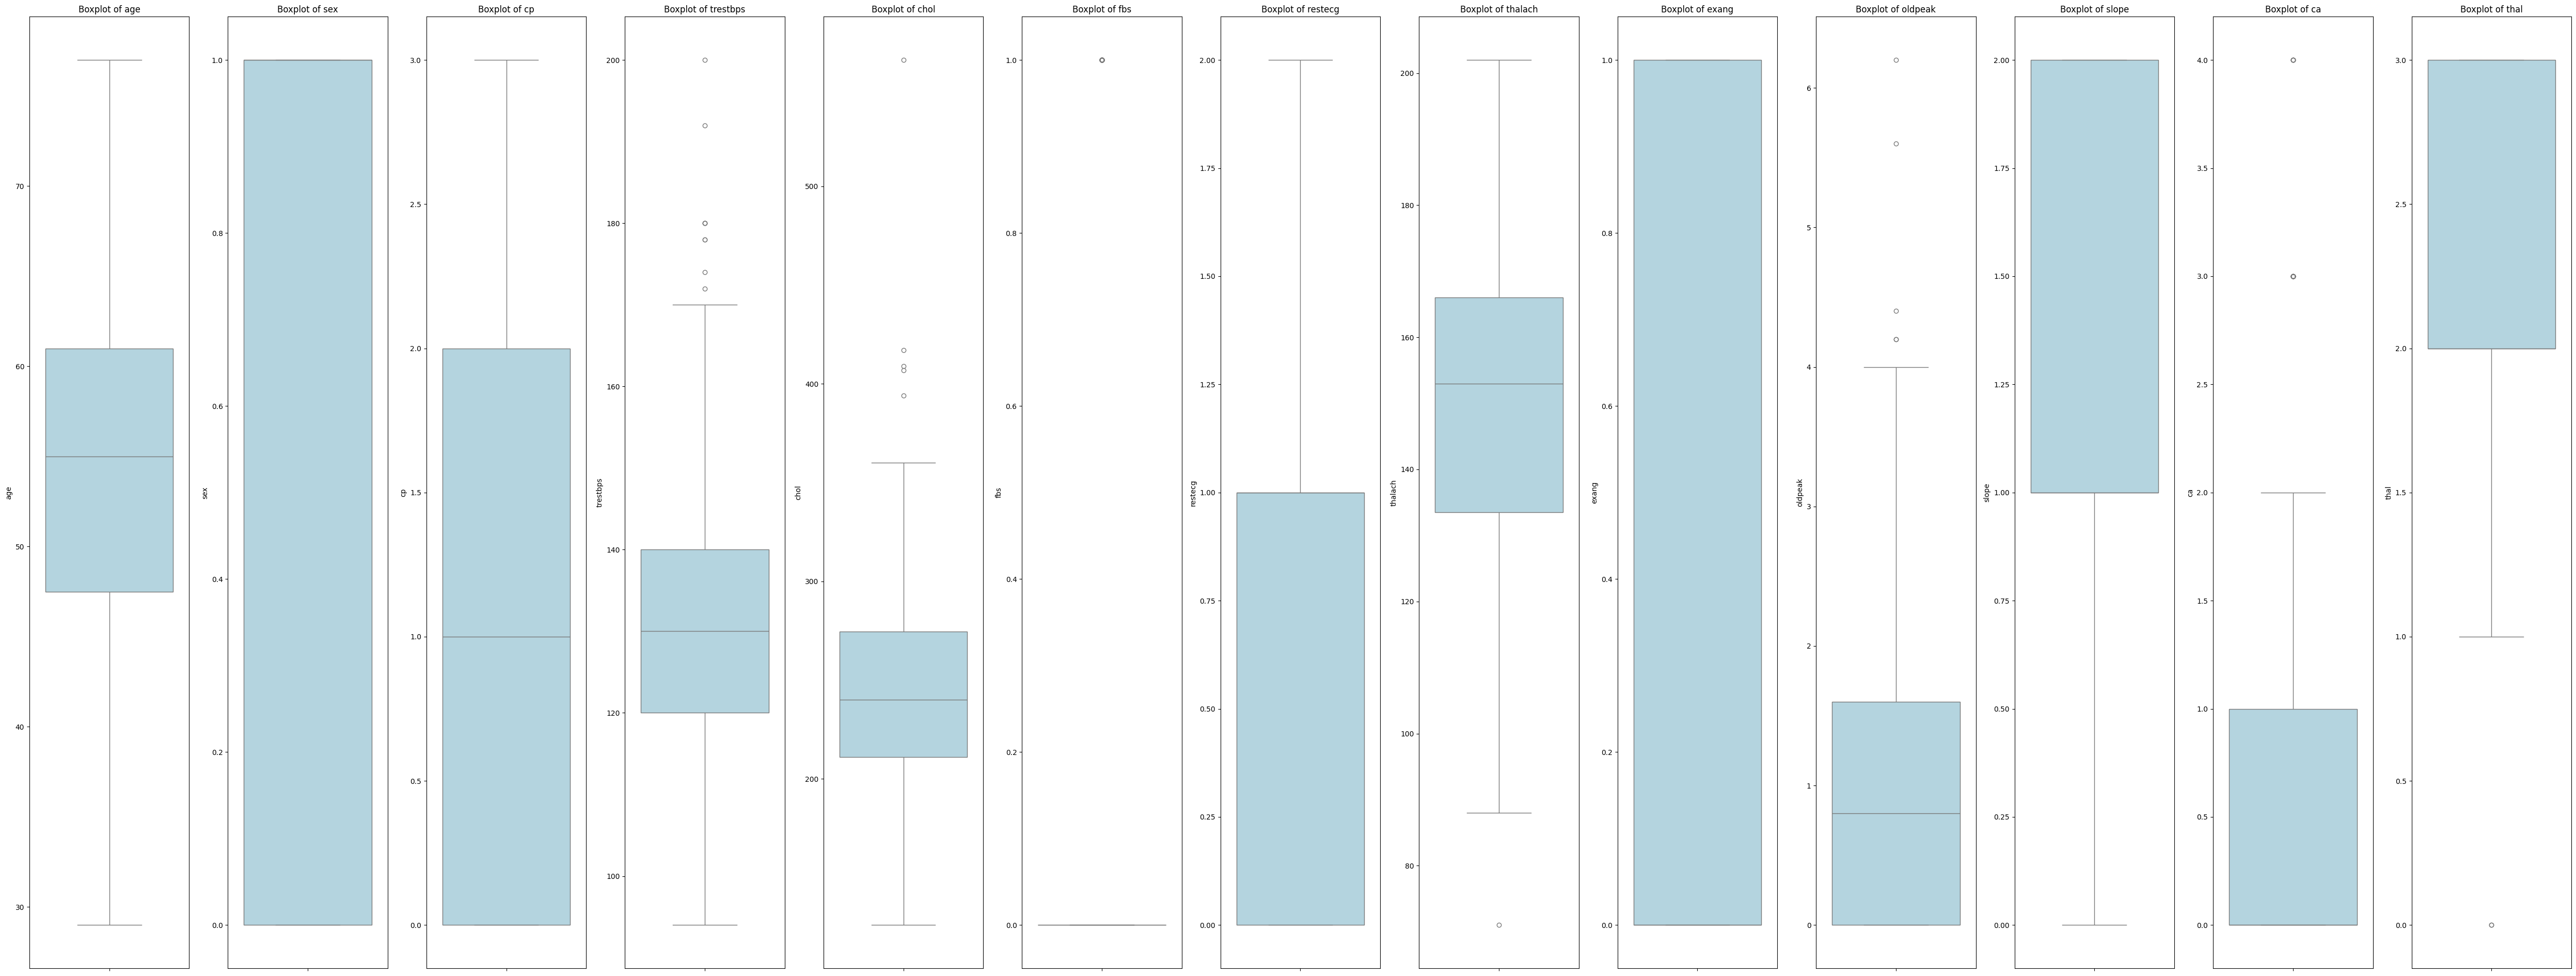

In [12]:
plt.figure(figsize=(50, 19))
for i, col in enumerate(X.columns):
    plt.subplot(1, len(X.columns), i + 1)
    sns.boxplot(y=X[col], color='lightblue')
    plt.title(f'Boxplot of {col}')
    plt.xlabel('')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

In [13]:
def IQR(data, col):
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    out = data[(data[col] < low) | (data[col] > high)]
    return len(out), low, high

for col in X.columns:
    length, low, high = IQR(X, col)
    print(f'Total number of outliers: {length}. For columns: {col}')
    # print(f'25th percintle: {low} and 75th percintle: {high}')

Total number of outliers: 0. For columns: age
Total number of outliers: 0. For columns: sex
Total number of outliers: 0. For columns: cp
Total number of outliers: 9. For columns: trestbps
Total number of outliers: 5. For columns: chol
Total number of outliers: 45. For columns: fbs
Total number of outliers: 0. For columns: restecg
Total number of outliers: 1. For columns: thalach
Total number of outliers: 0. For columns: exang
Total number of outliers: 5. For columns: oldpeak
Total number of outliers: 0. For columns: slope
Total number of outliers: 25. For columns: ca
Total number of outliers: 2. For columns: thal


In [14]:
def remove_outliers_clip(data, col):
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    return data[col].clip(lower=low, upper=high)

In [15]:
for col in X.columns:
    X[col] = remove_outliers_clip(X, col)

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer

In [17]:
num_features = [0, 3, 4, 7, 9]
cat_features = [1, 2, 5, 6, 8, 10, 11, 12]

num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_features),
        ('cat', cat_pipeline, cat_features)
    ],
    remainder='drop'
)

In [18]:
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.metrics import precision_recall_curve

Splitting the Data into Training data & Test Data

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2)

Model Training

In [20]:
model_1 = CatBoostClassifier(iterations=1000)

est_1 = Pipeline([
    ('preprocessor', preprocessor),
    ('est', model_1)
])

est_1.fit(X_train, y_train)

Learning rate set to 0.005621
0:	learn: 0.6884246	total: 151ms	remaining: 2m 30s
1:	learn: 0.6831315	total: 152ms	remaining: 1m 15s
2:	learn: 0.6789440	total: 153ms	remaining: 50.8s
3:	learn: 0.6746373	total: 154ms	remaining: 38.3s
4:	learn: 0.6704022	total: 155ms	remaining: 30.8s
5:	learn: 0.6653748	total: 156ms	remaining: 25.8s
6:	learn: 0.6609118	total: 157ms	remaining: 22.3s
7:	learn: 0.6561256	total: 158ms	remaining: 19.6s
8:	learn: 0.6512864	total: 159ms	remaining: 17.5s
9:	learn: 0.6466778	total: 160ms	remaining: 15.9s
10:	learn: 0.6432667	total: 161ms	remaining: 14.5s
11:	learn: 0.6391324	total: 162ms	remaining: 13.4s
12:	learn: 0.6359611	total: 164ms	remaining: 12.5s
13:	learn: 0.6312254	total: 166ms	remaining: 11.7s
14:	learn: 0.6260560	total: 167ms	remaining: 11s
15:	learn: 0.6208887	total: 169ms	remaining: 10.4s
16:	learn: 0.6178717	total: 170ms	remaining: 9.81s
17:	learn: 0.6133917	total: 171ms	remaining: 9.36s
18:	learn: 0.6089087	total: 173ms	remaining: 8.92s
19:	learn: 

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  [0, 3, 4, 7, 9]),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  [1, 2, 5, 6, 8, 10, 11,
                                                   12])])),
                ('est',
                 <catboost.core.CatBoostClassifier object at 0x000002BE03B57790>)])

In [21]:
model_2 = XGBClassifier(scale_pos_weight=10)

est_2 = Pipeline([
    ('preporcessor', preprocessor),
    ('est', model_2)
])

est_2.fit(X_train, y_train)

Pipeline(steps=[('preporcessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  [0, 3, 4, 7, 9]),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  [1, 2, 5, 6, 8, 10, 11,
                                                   12])])),
                ('est',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

Model Evaluation

In [22]:
def evaluate_model(model, X_test, y_test, model_name):
    """
    Generates a comprehensive evaluation dashboard for a classification model.
    Arguments:
        model: Trained estimator (or pipeline)
        X_test: Test features
        y_test: Test labels
        model_name: String name for the plot labels
    """
    
    # 1. Get Predictions
    # We need hard classes (0/1) for the Matrix/Report
    y_pred = model.predict(X_test)
    # We need probabilities for Log Loss and PR Curve
    y_proba = model.predict_proba(X_test)[:, 1] 

    # 2. Print Text Metrics
    print(f"--- {model_name} Evaluation ---")
    print(f"Log Loss: {log_loss(y_test, y_proba):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # 3. Generate Plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Plot Confusion Matrix
    ConfusionMatrixDisplay.from_predictions(
        y_test, 
        y_pred, 
        ax=ax1, 
        cmap='Blues', 
        colorbar=False
    )
    ax1.set_title("Confusion Matrix")

    # Plot Precision-Recall Curve
    # (Crucial for your unbalanced 'Outcome' data)
    PrecisionRecallDisplay.from_predictions(
        y_test, 
        y_proba, 
        ax=ax2, 
        name=model_name,
        plot_chance_level=True # Adds the baseline for context
    )
    ax2.set_title("Precision-Recall Curve")
    ax2.grid(linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

# --- Usage ---
# Assuming you have already split your data:
# evaluate_model(est_1, X_test, y_test)

--- CatBoostClassifier Evaluation ---
Log Loss: 0.4992

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.71      0.71        28
           1       0.76      0.76      0.76        33

    accuracy                           0.74        61
   macro avg       0.74      0.74      0.74        61
weighted avg       0.74      0.74      0.74        61



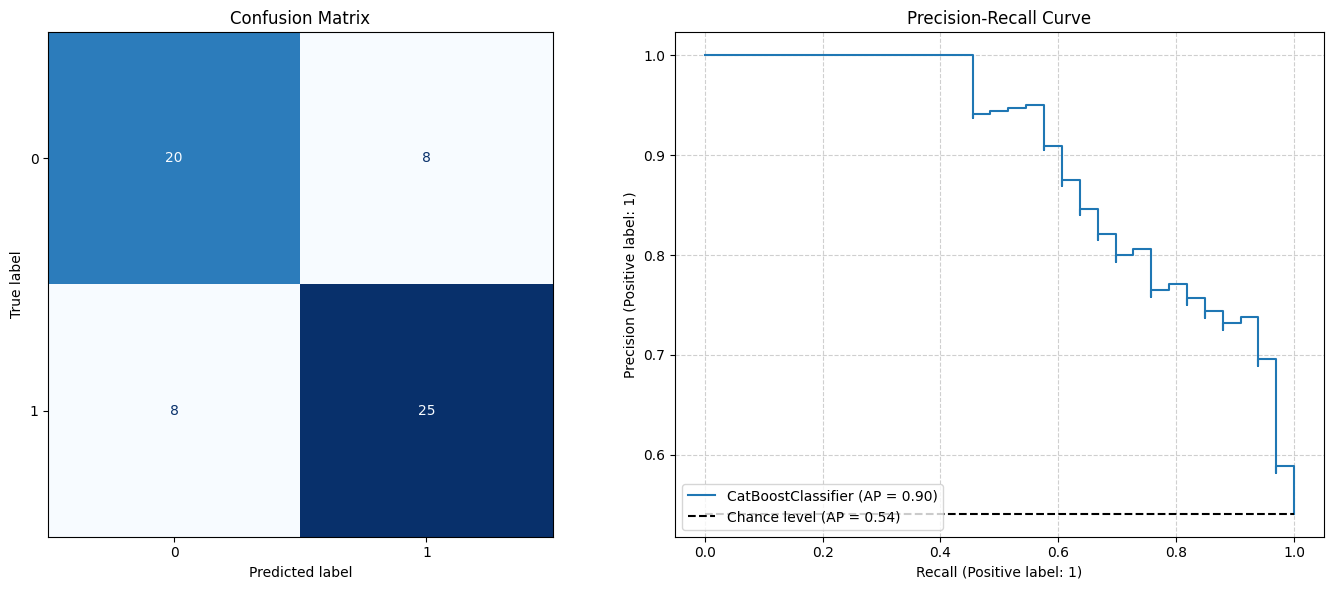

In [23]:
evaluate_model(model=est_1, X_test=X_test, y_test=y_test, model_name="CatBoostClassifier")

Building a Predictive System

--- XGBoostClassifier Evaluation ---
Log Loss: 0.8873

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.68      0.70        28
           1       0.74      0.79      0.76        33

    accuracy                           0.74        61
   macro avg       0.74      0.73      0.73        61
weighted avg       0.74      0.74      0.74        61



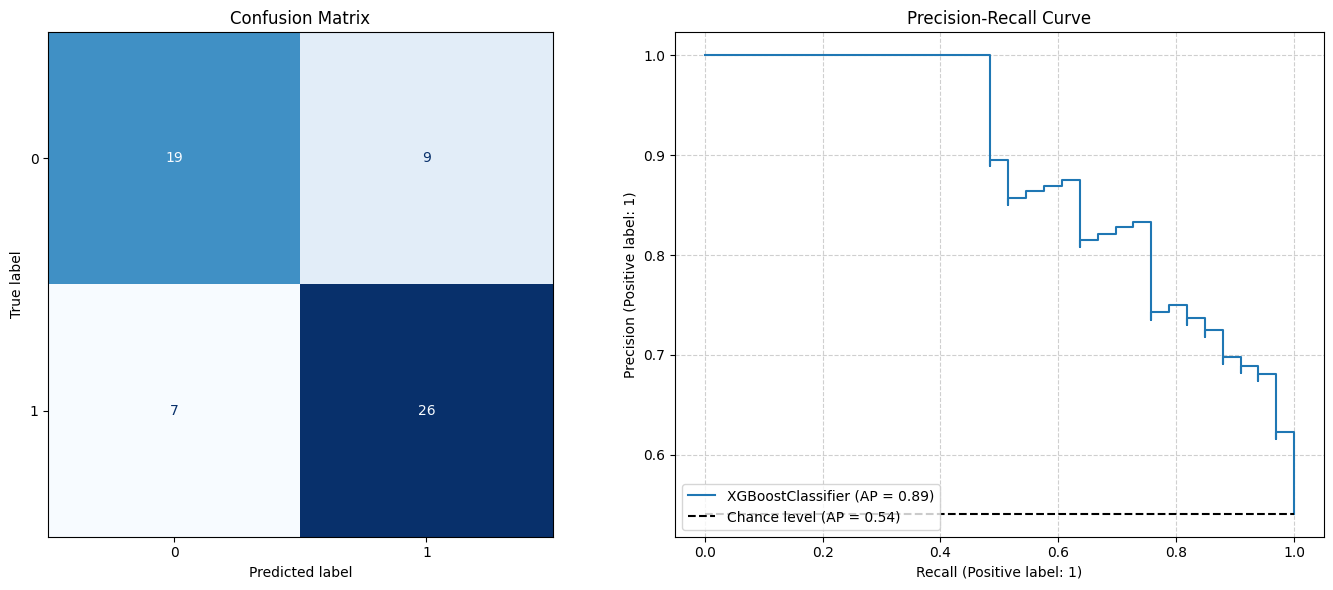

In [24]:
evaluate_model(model=est_2, X_test=X_test, y_test=y_test, model_name="XGBoostClassifier")

In [25]:
model = CatBoostClassifier(auto_class_weights='Balanced', iterations=1000)

est = Pipeline([
    ('preprocessor', preprocessor),
    ('est', model_1)
])

est.fit(X, Y)

Learning rate set to 0.006187
0:	learn: 0.6878302	total: 1.85ms	remaining: 1.85s
1:	learn: 0.6826406	total: 3.2ms	remaining: 1.6s
2:	learn: 0.6772032	total: 4.47ms	remaining: 1.48s
3:	learn: 0.6748163	total: 5.18ms	remaining: 1.29s
4:	learn: 0.6723023	total: 5.9ms	remaining: 1.17s
5:	learn: 0.6682884	total: 6.74ms	remaining: 1.11s
6:	learn: 0.6642172	total: 7.67ms	remaining: 1.09s
7:	learn: 0.6604791	total: 8.61ms	remaining: 1.07s
8:	learn: 0.6577340	total: 9.3ms	remaining: 1.02s
9:	learn: 0.6523811	total: 10.2ms	remaining: 1.01s
10:	learn: 0.6489294	total: 11.3ms	remaining: 1.01s
11:	learn: 0.6450137	total: 12.3ms	remaining: 1.01s
12:	learn: 0.6408712	total: 13.3ms	remaining: 1.01s
13:	learn: 0.6368603	total: 14.3ms	remaining: 1.01s
14:	learn: 0.6329618	total: 15.5ms	remaining: 1.02s
15:	learn: 0.6290586	total: 16.6ms	remaining: 1.02s
16:	learn: 0.6254199	total: 17.6ms	remaining: 1.02s
17:	learn: 0.6213924	total: 18.6ms	remaining: 1.01s
18:	learn: 0.6176972	total: 19.6ms	remaining: 1.

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  [0, 3, 4, 7, 9]),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  [1, 2, 5, 6, 8, 10, 11,
                                                   12])])),
                ('est',
                 <catboost.core.CatBoostClassifier object at 0x000002BE03B57790>)])

In [26]:
input_data = (62,0,0,140,268,0,0,160,0,3.6,0,2,2)

# change the input data to a numpy array
input_data_as_numpy_array= np.asarray(input_data)

# reshape the numpy array as we are predicting for only on instance
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

prediction = est_1.predict(input_data_reshaped)
print(prediction)

if (prediction[0]== 0):
  print('The Person does not have a Heart Disease')
else:
  print('The Person has Heart Disease')

[0]
The Person does not have a Heart Disease


c:\Users\visha\OneDrive\Desktop\projects\Multiple_Heath_Disease_Predictor\myenv\Lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
c:\Users\visha\OneDrive\Desktop\projects\Multiple_Heath_Disease_Predictor\myenv\Lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


Saving the trained model

In [27]:
import pickle

In [28]:
filename = 'C:\\Users\\visha\\OneDrive\\Desktop\\projects\\Multiple_Heath_Disease_Predictor\\application\\saved_models\\heart_model.sav'
pickle.dump(est, open(filename, 'wb'))